# FP MCI — Machine Learning: Post-Delivery Low-Rating Risk Estimator

**Persona:** Customer Experience Analyst  
**Business Problem:** Mengidentifikasi risiko low rating pada customer journey setelah proses fulfillment/pengiriman.  
**Model Role:** Komponen pendukung risk simulator — bukan pusat utama project.  
**Framing:** Post-delivery / post-fulfillment low-rating risk estimator.

> **Catatan metodologi:** Model ini memiliki performa moderat (ROC-AUC sekitar 0.72–0.76 yang dapat diharapkan dari data perilaku e-commerce). Performa tersebut **cukup untuk digunakan sebagai risk scoring simulator**, tetapi tidak diklaim sebagai model prediksi kausal atau sistem prediksi operasional yang sangat kuat. Keterbatasan utama adalah sebagian besar sinyal yang tersedia baru diketahui setelah proses fulfillment selesai.

---
**Output model:**
- `low_rating_risk` — estimasi probabilitas low rating (0–1)
- `low_rating_risk_percentage` — probabilitas dalam persen
- `risk_level` — kategori Low / Medium / High
- `business_interpretation` — teks narasi untuk web simulator

**Split strategy:** Train (60%) → Calibration-Validation (20%) → Final Test (20%).  
Final test set **tidak menyentuh** proses fitting, kalibrasi, atau early stopping.

## 1. Setup & Environment

### 1.1 Mount Google Drive
Seluruh artefak ML disimpan ke Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.2 Definisi Path Output
Path terstruktur: `models/`, `plots/`, dan root untuk CSV output.

In [2]:
import os

BASE_PATH  = '/content/drive/MyDrive/FP_MCI_Data/Dataset'
MODEL_PATH = os.path.join(BASE_PATH, 'models')
PLOT_PATH  = os.path.join(BASE_PATH, 'plots')

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(PLOT_PATH,  exist_ok=True)

print(f'BASE  : {BASE_PATH}')
print(f'MODEL : {MODEL_PATH}')
print(f'PLOTS : {PLOT_PATH}')

BASE  : /content/drive/MyDrive/FP_MCI_Data/Dataset
MODEL : /content/drive/MyDrive/FP_MCI_Data/Dataset/models
PLOTS : /content/drive/MyDrive/FP_MCI_Data/Dataset/plots


### 1.3 Import Library

In [3]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import OrdinalEncoder
from sklearn.impute            import SimpleImputer
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import HistGradientBoostingClassifier
from sklearn.calibration       import CalibratedClassifierCV, calibration_curve
from sklearn.metrics           import (
    classification_report, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from sklearn.inspection        import permutation_importance
import lightgbm as lgb

RANDOM_STATE = 42
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


## 2. Load Dataset

### 2.1 Baca Semua CSV dari Drive

In [4]:
orders    = pd.read_csv(os.path.join(BASE_PATH, 'orders.csv'),
                         parse_dates=['order_purchase_timestamp','order_approved_at',
                                      'order_delivered_carrier_date',
                                      'order_delivered_customer_date',
                                      'order_estimated_delivery_date'])
reviews   = pd.read_csv(os.path.join(BASE_PATH, 'order_reviews.csv'))
items     = pd.read_csv(os.path.join(BASE_PATH, 'order_items.csv'))
payments  = pd.read_csv(os.path.join(BASE_PATH, 'order_payments.csv'))
customers = pd.read_csv(os.path.join(BASE_PATH, 'customers.csv'))
sellers   = pd.read_csv(os.path.join(BASE_PATH, 'sellers.csv'))
products  = pd.read_csv(os.path.join(BASE_PATH, 'products.csv'))
cat_trans = pd.read_csv(os.path.join(BASE_PATH, 'category_translation.csv'))

### 2.2 Ringkasan Shape Dataset

In [5]:
datasets = {
    'orders': orders, 'reviews': reviews, 'items': items,
    'payments': payments, 'customers': customers,
    'sellers': sellers, 'products': products, 'cat_trans': cat_trans
}
for name, df_ in datasets.items():
    print(f'{name:12s}: {df_.shape[0]:>7,} rows  x  {df_.shape[1]} cols')

orders      :  99,441 rows  x  8 cols
reviews     :  99,224 rows  x  7 cols
items       : 112,650 rows  x  7 cols
payments    : 103,886 rows  x  5 cols
customers   :  99,441 rows  x  5 cols
sellers     :   3,095 rows  x  4 cols
products    :  32,951 rows  x  9 cols
cat_trans   :      71 rows  x  2 cols


## 3. Feature Engineering

> Seluruh fitur dibangun dari atribut struktural order (waktu, lokasi, produk, pembayaran).
> Review text (`review_comment_title`, `review_comment_message`) **tidak digunakan** untuk menghindari data leakage.
> Fitur agregat historis berbasis review score (misal rata-rata rating seller) **juga tidak digunakan** karena rawan leakage cross-order.

### 3.1 Fitur Delivery dari `orders`
Durasi tiap tahap pengiriman (hari) dan flag keterlambatan vs estimasi.

In [6]:
ord_feat = orders[[
    'order_id', 'order_status',
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]].copy()

ord_feat['approval_delay_days'] = (
    ord_feat['order_approved_at'] - ord_feat['order_purchase_timestamp']
).dt.total_seconds() / 86400

ord_feat['carrier_delay_days'] = (
    ord_feat['order_delivered_carrier_date'] - ord_feat['order_approved_at']
).dt.total_seconds() / 86400

ord_feat['last_mile_days'] = (
    ord_feat['order_delivered_customer_date'] - ord_feat['order_delivered_carrier_date']
).dt.total_seconds() / 86400

ord_feat['estimated_delivery_days'] = (
    ord_feat['order_estimated_delivery_date'] - ord_feat['order_purchase_timestamp']
).dt.total_seconds() / 86400

ord_feat['actual_delivery_days'] = (
    ord_feat['order_delivered_customer_date'] - ord_feat['order_purchase_timestamp']
).dt.total_seconds() / 86400

ord_feat['delivery_delay_vs_estimate'] = (
    ord_feat['actual_delivery_days'] - ord_feat['estimated_delivery_days']
)

ord_feat['is_late'] = (ord_feat['delivery_delay_vs_estimate'] > 0).astype(int)

# Hanya order berstatus delivered
ord_feat = ord_feat[ord_feat['order_status'] == 'delivered'].copy()

keep = ['order_id', 'approval_delay_days', 'carrier_delay_days', 'last_mile_days',
        'estimated_delivery_days', 'actual_delivery_days',
        'delivery_delay_vs_estimate', 'is_late']
ord_feat = ord_feat[keep]
print(f'Delivered orders: {len(ord_feat):,}')

Delivered orders: 96,478


### 3.2 Fitur Item dari `order_items`
Agregasi per order: jumlah item, seller unik, total/rata-rata harga & ongkir, rasio ongkir-harga.

In [7]:
item_feat = items.groupby('order_id').agg(
    item_count      = ('order_item_id',  'count'),
    seller_count    = ('seller_id',      'nunique'),
    total_price     = ('price',          'sum'),
    avg_price       = ('price',          'mean'),
    total_freight   = ('freight_value',  'sum'),
    avg_freight     = ('freight_value',  'mean'),
    main_seller_id  = ('seller_id',      lambda x: x.mode()[0]),
    main_product_id = ('product_id',     lambda x: x.mode()[0]),
).reset_index()

item_feat['freight_to_price_ratio'] = (
    item_feat['total_freight'] / item_feat['total_price'].replace(0, np.nan)
)
print(f'Item features: {item_feat.shape}')

Item features: (98666, 10)


### 3.3 Fitur Pembayaran dari `order_payments`
Total pembayaran, jumlah metode, metode utama, dan cicilan maksimum.

In [8]:
pay_feat = payments.groupby('order_id').agg(
    total_payment_value      = ('payment_value',        'sum'),
    payment_method_count     = ('payment_type',         'nunique'),
    main_payment_type        = ('payment_type',         lambda x: x.mode()[0]),
    max_payment_installments = ('payment_installments', 'max'),
).reset_index()
print(f'Payment features: {pay_feat.shape}')

Payment features: (99440, 5)


### 3.4 Fitur Lokasi Pelanggan dari `customers`

In [9]:
cust_feat = (
    orders[['order_id', 'customer_id']]
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    [['order_id', 'customer_state', 'customer_city']]
)
print(f'Customer features: {cust_feat.shape}')

Customer features: (99441, 3)


### 3.5 Fitur Lokasi Seller + Flag Same-State dari `sellers`

In [10]:
seller_base = (
    item_feat[['order_id', 'main_seller_id']]
    .merge(sellers[['seller_id', 'seller_state', 'seller_city']],
           left_on='main_seller_id', right_on='seller_id', how='left')
    [['order_id', 'seller_state', 'seller_city']]
)

seller_feat = seller_base.merge(
    cust_feat[['order_id', 'customer_state']], on='order_id', how='left'
)
seller_feat['same_customer_seller_state'] = (
    seller_feat['seller_state'] == seller_feat['customer_state']
).astype(int)
seller_feat = seller_feat[['order_id', 'seller_state', 'seller_city', 'same_customer_seller_state']]
print(f'Seller features: {seller_feat.shape}')

Seller features: (98666, 4)


### 3.6 Fitur Produk & Kategori dari `products` + `category_translation`
Kategori ditranslasikan ke Bahasa Inggris. Volume produk dihitung dari dimensi (l×h×w).

In [11]:
prod = products.merge(cat_trans, on='product_category_name', how='left')
prod['product_volume_cm3'] = (
    prod['product_length_cm'] * prod['product_height_cm'] * prod['product_width_cm']
)

prod_feat = (
    item_feat[['order_id', 'main_product_id']]
    .merge(prod[['product_id', 'product_category_name_english',
                 'product_weight_g', 'product_volume_cm3']],
           left_on='main_product_id', right_on='product_id', how='left')
    .rename(columns={'product_category_name_english': 'main_product_category'})
    [['order_id', 'main_product_category', 'product_weight_g', 'product_volume_cm3']]
)
print(f'Product features: {prod_feat.shape}')

Product features: (98666, 4)


### 3.7 Gabungkan Semua Fitur
Join bertahap dari `ord_feat` (base: delivered orders) ke semua fitur tambahan.

In [12]:
df = ord_feat.copy()
df = df.merge(item_feat.drop(columns=['main_seller_id', 'main_product_id']), on='order_id', how='left')
df = df.merge(pay_feat,    on='order_id', how='left')
df = df.merge(cust_feat,   on='order_id', how='left')
df = df.merge(seller_feat, on='order_id', how='left')
df = df.merge(prod_feat,   on='order_id', how='left')
print(f'Feature DataFrame (sebelum label): {df.shape}')

Feature DataFrame (sebelum label): (96478, 27)


### 3.8 Buat Label Target `low_rating`
- `low_rating = 1` jika `review_score <= 2`  
- `low_rating = 0` jika `review_score > 2`  

Review text (`review_comment_title`, `review_comment_message`) **tidak diikutsertakan** sebagai fitur.

In [13]:
# Ambil satu review per order — jika ada duplikat, ambil yang terakhir dicreate
rev = (
    reviews[['order_id', 'review_score', 'review_creation_date']]
    .sort_values('review_creation_date')
    .drop_duplicates(subset='order_id', keep='last')
)
rev['low_rating'] = (rev['review_score'] <= 2).astype(int)

df = df.merge(rev[['order_id', 'review_score', 'low_rating']], on='order_id', how='inner')
print(f'Dataset setelah join label: {df.shape}')
print(f'Low rating rate           : {df["low_rating"].mean()*100:.2f}%')

Dataset setelah join label: (95832, 29)
Low rating rate           : 12.81%


## 4. Eksplorasi Data (EDA)

### 4.1 Distribusi Review Score & Class Imbalance

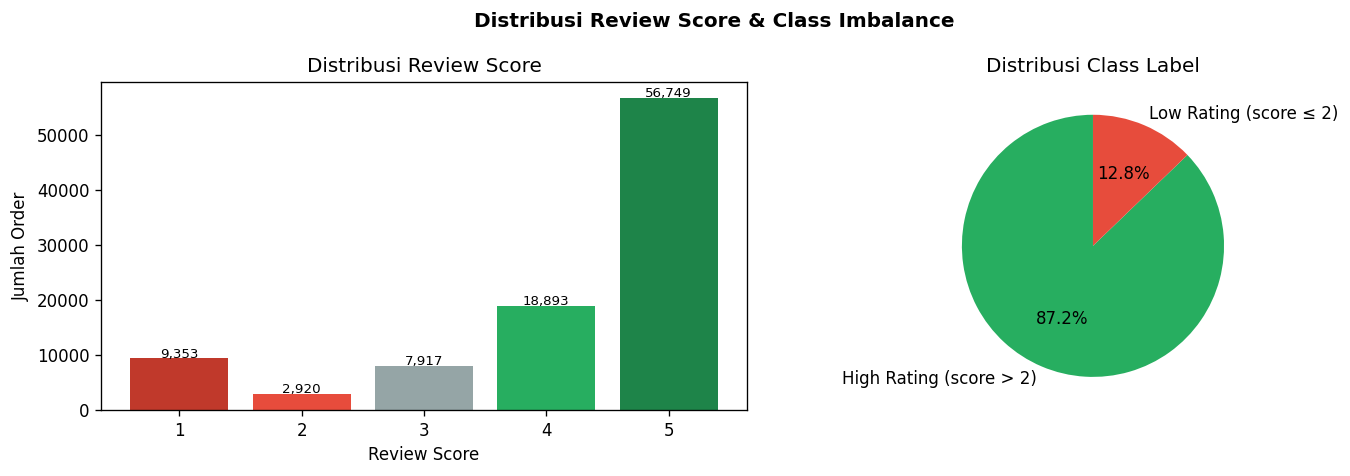

Imbalance ratio (0:1) = 6.8:1


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

score_counts = df['review_score'].value_counts().sort_index()
bar_colors = ['#c0392b', '#e74c3c', '#95a5a6', '#27ae60', '#1e8449']
axes[0].bar(score_counts.index, score_counts.values, color=bar_colors)
axes[0].set_title('Distribusi Review Score')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Jumlah Order')
for sc, cnt in score_counts.items():
    axes[0].text(sc, cnt + 200, f'{cnt:,}', ha='center', fontsize=8)

label_counts = df['low_rating'].value_counts()
axes[1].pie(
    [label_counts.get(0,0), label_counts.get(1,0)],
    labels=['High Rating (score > 2)', 'Low Rating (score ≤ 2)'],
    colors=['#27ae60', '#e74c3c'], autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Distribusi Class Label')

plt.suptitle('Distribusi Review Score & Class Imbalance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '01_label_distribution.png'), bbox_inches='tight')
plt.show()

ratio = label_counts.get(0,1) / max(label_counts.get(1,1), 1)
print(f'Imbalance ratio (0:1) = {ratio:.1f}:1')

### 4.2 Distribusi Fitur Delivery: Low vs High Rating

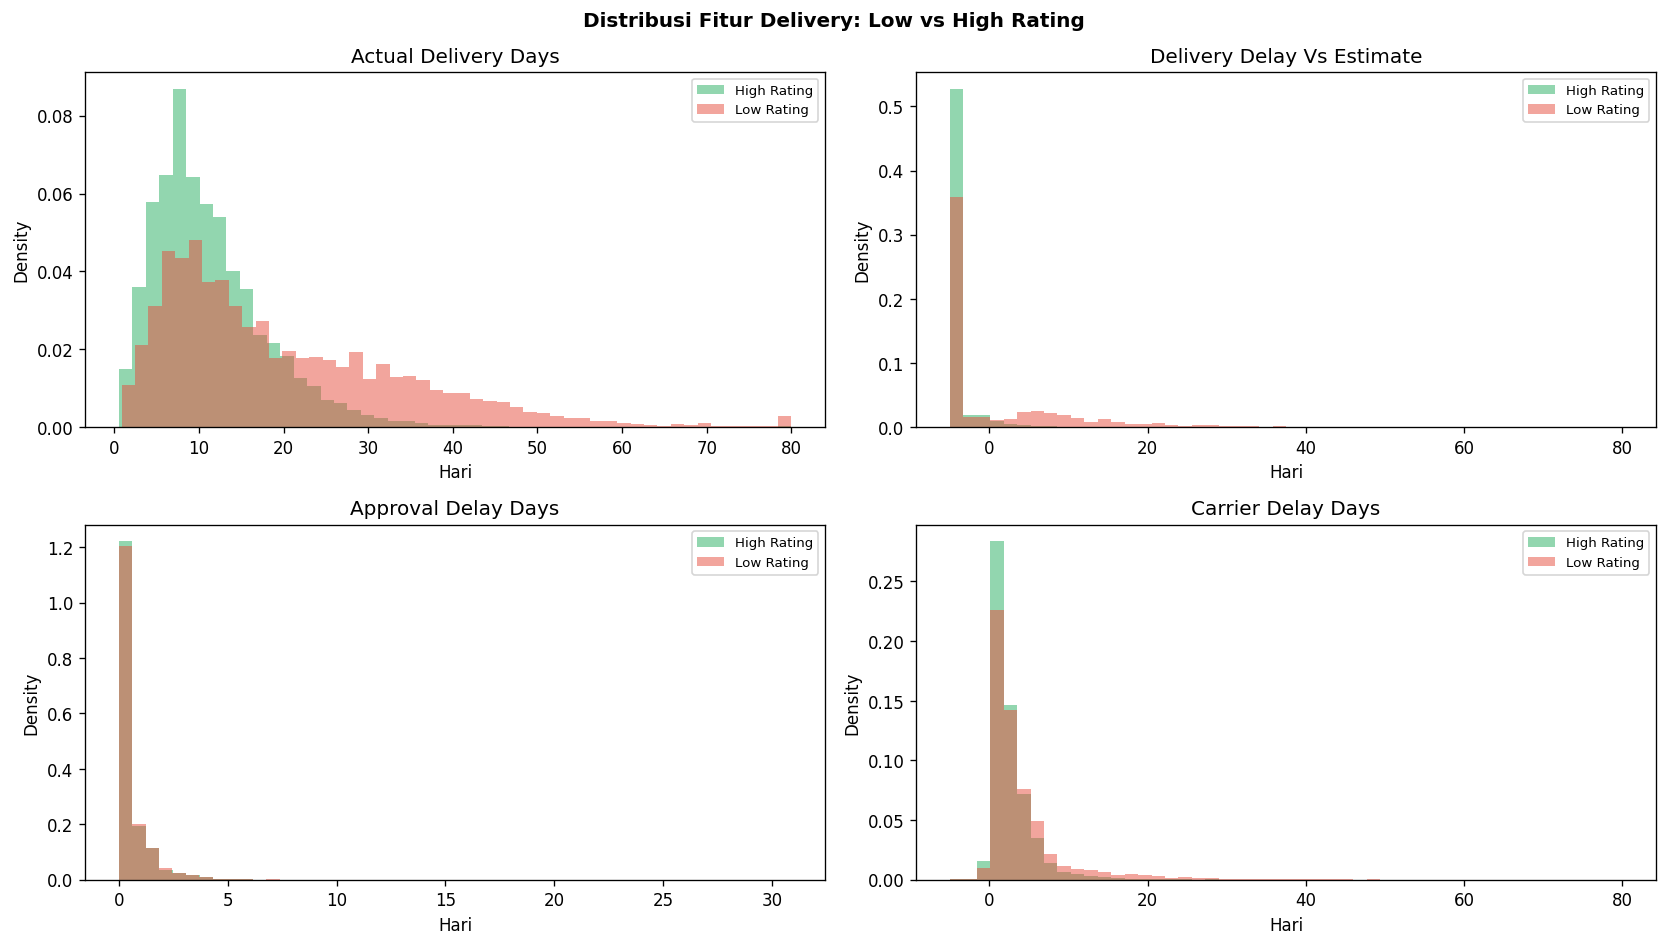

In [15]:
delivery_cols = [
    'actual_delivery_days', 'delivery_delay_vs_estimate',
    'approval_delay_days', 'carrier_delay_days'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(delivery_cols):
    for lv, color, name in [(0, '#27ae60', 'High Rating'), (1, '#e74c3c', 'Low Rating')]:
        data = df[df['low_rating'] == lv][col].dropna().clip(-5, 80)
        axes[i].hist(data, bins=50, alpha=0.5, color=color, label=name, density=True)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Hari')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Delivery: Low vs High Rating', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '02_delivery_distribution.png'), bbox_inches='tight')
plt.show()

### 4.3 Korelasi Fitur Numerik dengan Label

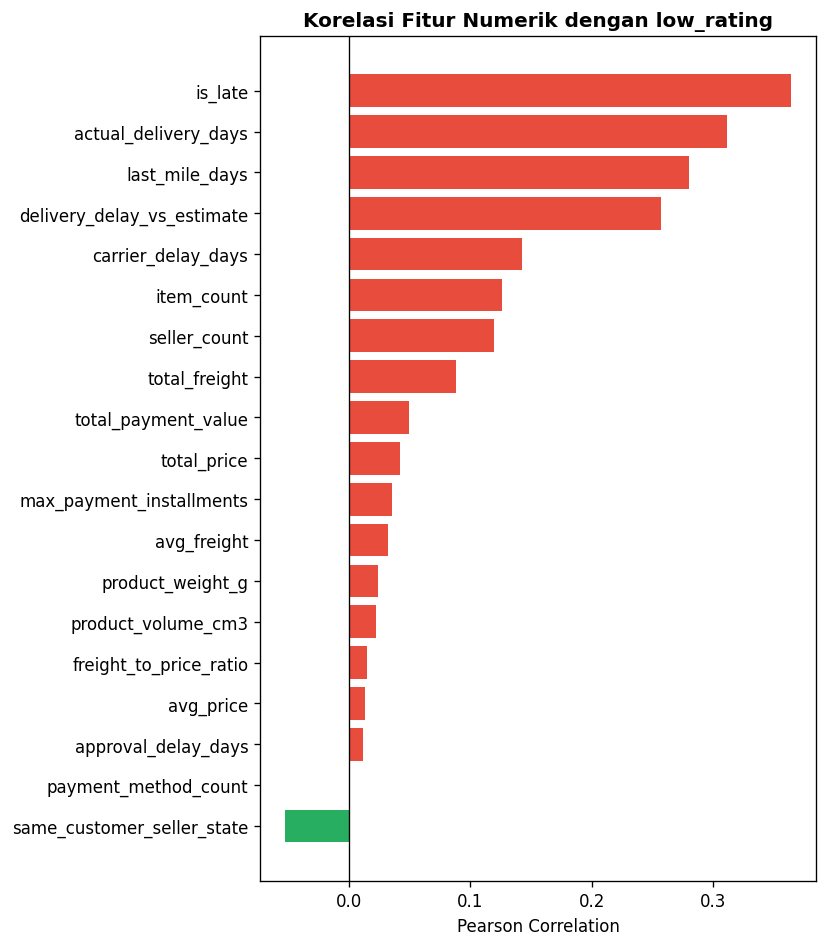

In [16]:
num_cols_eda = [
    'approval_delay_days', 'carrier_delay_days', 'last_mile_days',
    'actual_delivery_days', 'delivery_delay_vs_estimate', 'is_late',
    'item_count', 'seller_count', 'total_price', 'avg_price',
    'total_freight', 'avg_freight', 'freight_to_price_ratio',
    'total_payment_value', 'payment_method_count', 'max_payment_installments',
    'product_weight_g', 'product_volume_cm3', 'same_customer_seller_state'
]

corr = (
    df[num_cols_eda + ['low_rating']]
    .corr()['low_rating']
    .drop('low_rating')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 8))
bar_colors_corr = ['#e74c3c' if v > 0 else '#27ae60' for v in corr.values]
ax.barh(corr.index, corr.values, color=bar_colors_corr)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur Numerik dengan low_rating', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '03_feature_correlation.png'), bbox_inches='tight')
plt.show()

### 4.4 Low Rating Rate per Customer State

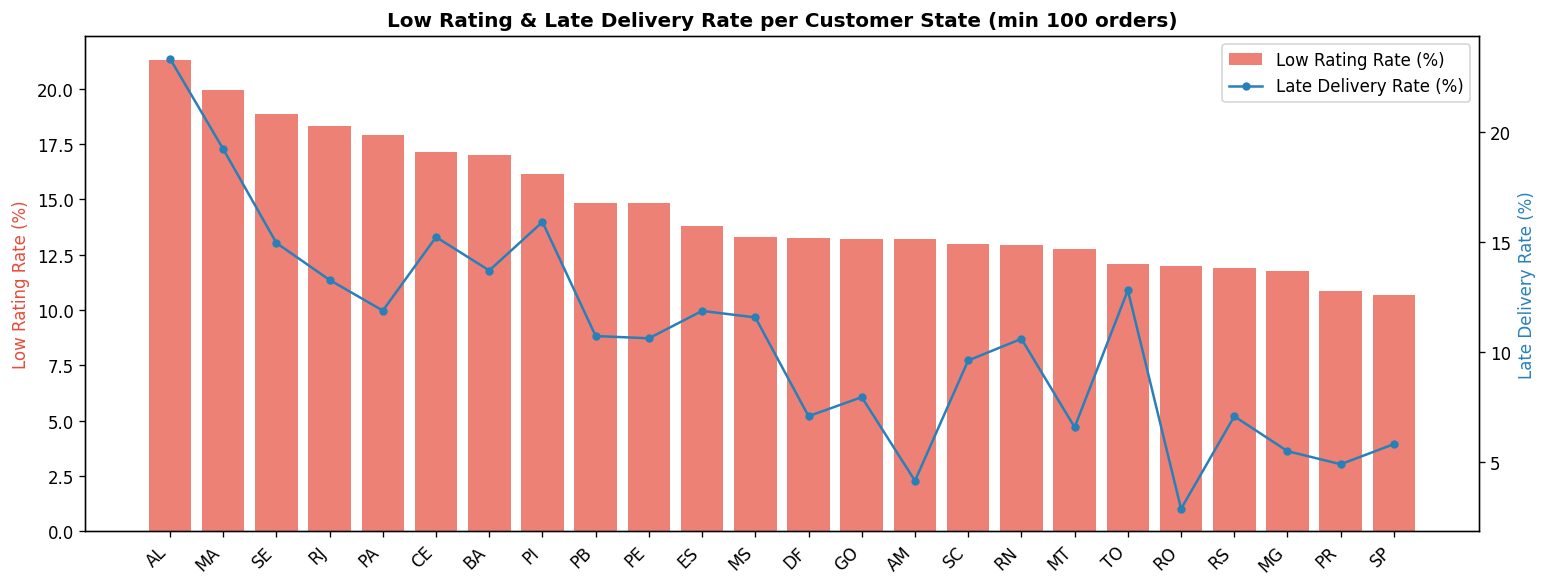

In [17]:
state_agg = df.groupby('customer_state').agg(
    n_orders     = ('order_id',    'count'),
    low_rate_pct = ('low_rating',  'mean'),
    late_pct     = ('is_late',     'mean'),
).reset_index()
state_agg = state_agg[state_agg['n_orders'] >= 100].sort_values('low_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(state_agg))
ax.bar(x, state_agg['low_rate_pct'] * 100, color='#e74c3c', alpha=0.7, label='Low Rating Rate (%)')
ax2 = ax.twinx()
ax2.plot(x, state_agg['late_pct'] * 100, 'o-', color='#2980b9',
         linewidth=1.5, markersize=4, label='Late Delivery Rate (%)')
ax.set_xticks(list(x))
ax.set_xticklabels(state_agg['customer_state'], rotation=45, ha='right')
ax.set_ylabel('Low Rating Rate (%)', color='#e74c3c')
ax2.set_ylabel('Late Delivery Rate (%)', color='#2980b9')
ax.set_title('Low Rating & Late Delivery Rate per Customer State (min 100 orders)', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '04_state_lowrating.png'), bbox_inches='tight')
plt.show()

## 5. Split Data: Train / Calibration-Val / Final Test

Split dilakukan **sebelum** preprocessing apa pun agar tidak terjadi data leakage dari test set.

| Split | Proporsi | Fungsi |
|---|---|---|
| Train | 60% | Fitting model & imputer/encoder |
| Calibration-Val | 20% | Early stopping, hyperparameter CV, kalibrasi probabilitas |
| Final Test | 20% | Evaluasi **sekali** di akhir, tidak menyentuh proses lain |

### 5.1 Pilih Kolom Fitur Final

In [18]:
FEATURE_COLS = [
    # Delivery timing
    'approval_delay_days', 'carrier_delay_days', 'last_mile_days',
    'estimated_delivery_days', 'actual_delivery_days',
    'delivery_delay_vs_estimate', 'is_late',
    # Item
    'item_count', 'seller_count',
    'total_price', 'avg_price',
    'total_freight', 'avg_freight', 'freight_to_price_ratio',
    # Payment
    'total_payment_value', 'payment_method_count',
    'main_payment_type', 'max_payment_installments',
    # Location
    'customer_state', 'seller_state',
    'same_customer_seller_state',
    # Product
    'main_product_category', 'product_weight_g', 'product_volume_cm3',
]

TARGET_COL = 'low_rating'

# Pisahkan jenis fitur untuk preprocessing
CAT_COLS = ['main_payment_type', 'customer_state', 'seller_state', 'main_product_category']
NUM_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS]

print(f'Total fitur : {len(FEATURE_COLS)}')
print(f'Numerik     : {len(NUM_COLS)}')
print(f'Kategorik   : {len(CAT_COLS)}')

Total fitur : 24
Numerik     : 20
Kategorik   : 4


### 5.2 Stratified Split 60 / 20 / 20
Stratified split memastikan proporsi `low_rating` terjaga di setiap split.

In [19]:
df_ml = df[['order_id'] + FEATURE_COLS + [TARGET_COL, 'review_score']].copy()

X_all = df_ml[FEATURE_COLS]
y_all = df_ml[TARGET_COL]

# Step 1: pisahkan final test (20%) — tidak disentuh lagi
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=RANDOM_STATE, stratify=y_all
)

# Step 2: dari sisa 80%, ambil calibration-val (25% dari sisa = 20% total)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train          : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X_all)*100:.0f}%)')
print(f'Calibration-Val: {X_cal.shape[0]:,} rows ({X_cal.shape[0]/len(X_all)*100:.0f}%)')
print(f'Final Test     : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X_all)*100:.0f}%)')
print()
print(f'Low rating — Train     : {y_train.mean()*100:.2f}%')
print(f'Low rating — Cal-Val   : {y_cal.mean()*100:.2f}%')
print(f'Low rating — Final Test: {y_test.mean()*100:.2f}%')

Train          : 57,498 rows (60%)
Calibration-Val: 19,167 rows (20%)
Final Test     : 19,167 rows (20%)

Low rating — Train     : 12.81%
Low rating — Cal-Val   : 12.81%
Low rating — Final Test: 12.81%


## 6. Preprocessing Pipeline

> Imputer dan encoder di-fit **hanya pada `X_train`**, kemudian di-transform ke `X_cal` dan `X_test`.
> Ini mencegah data leakage dari distribusi validation/test masuk ke proses training.

### 6.1 Definisi Pipeline Preprocessing
Numerik: median imputation. Kategorik: most-frequent imputation + OrdinalEncoder.

In [20]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        encoded_missing_value=-1
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, NUM_COLS),
        ('cat', cat_pipeline, CAT_COLS),
    ],
    remainder='drop'
)
print('Preprocessing pipeline defined.')

Preprocessing pipeline defined.


### 6.2 Fit pada Train, Transform ke Semua Split
Preprocessor hanya di-fit satu kali pada `X_train`.

In [21]:
# Fit HANYA pada training data
preprocessor.fit(X_train)

# Transform masing-masing split secara terpisah
X_train_p = preprocessor.transform(X_train)
X_cal_p   = preprocessor.transform(X_cal)
X_test_p  = preprocessor.transform(X_test)

# Nama kolom setelah transform (untuk feature importance)
feature_names_out = NUM_COLS + CAT_COLS

# Buat DataFrame agar compatible dengan sklearn.inspection
X_train_df = pd.DataFrame(X_train_p, columns=feature_names_out)
X_cal_df   = pd.DataFrame(X_cal_p,   columns=feature_names_out)
X_test_df  = pd.DataFrame(X_test_p,  columns=feature_names_out)

print(f'X_train shape setelah preprocessing: {X_train_df.shape}')
print(f'X_cal   shape setelah preprocessing: {X_cal_df.shape}')
print(f'X_test  shape setelah preprocessing: {X_test_df.shape}')

X_train shape setelah preprocessing: (57498, 24)
X_cal   shape setelah preprocessing: (19167, 24)
X_test  shape setelah preprocessing: (19167, 24)


## 7. Perbandingan Model: HistGradientBoosting vs LightGBM

CV sebelumnya menunjukkan HistGradientBoosting memiliki ROC-AUC yang sedikit lebih tinggi atau setara dengan LightGBM.
Perbandingan dilakukan secara **fair** menggunakan 5-Fold CV pada `X_train` saja.

LightGBM dipilih sebagai model final bukan karena "CV terbaik", melainkan karena:
1. Mendukung `early_stopping` dengan `eval_set` eksplisit tanpa data leakage
2. Output probabilitas lebih mudah dikalibrasi dengan `CalibratedClassifierCV`
3. `feature_importances_` mudah di-extract untuk simulator readiness
4. Packaging `.pkl` lebih ringan dan portabel untuk deployment app
5. `scale_pos_weight` memberikan kontrol eksplisit atas class imbalance

Jika HistGradientBoosting unggul signifikan (>0.01 AUC) secara konsisten, pilihan model akan direvisi.

### 7.1 5-Fold Cross Validation pada Train Set

In [22]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight: {spw:.2f}  (neg/pos = {neg_count:,}/{pos_count:,})')

cv_models = {
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=500, learning_rate=0.05, max_depth=6,
        min_samples_leaf=30, random_state=RANDOM_STATE
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=7, num_leaves=63,
        scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in cv_models.items():
    auc = cross_val_score(model, X_train_df, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    ap  = cross_val_score(model, X_train_df, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
    cv_results[name] = {'roc_auc_mean': auc.mean(), 'roc_auc_std': auc.std(),
                        'ap_mean': ap.mean(), 'ap_std': ap.std()}
    print(f'{name:25s} | ROC-AUC: {auc.mean():.4f} ± {auc.std():.4f}  '
          f'| AP: {ap.mean():.4f} ± {ap.std():.4f}')

scale_pos_weight: 6.81  (neg/pos = 50,135/7,363)
HistGradientBoosting      | ROC-AUC: 0.7571 ± 0.0027  | AP: 0.4624 ± 0.0105
LightGBM                  | ROC-AUC: 0.7383 ± 0.0030  | AP: 0.4444 ± 0.0086


### 7.2 Visualisasi Perbandingan CV Score

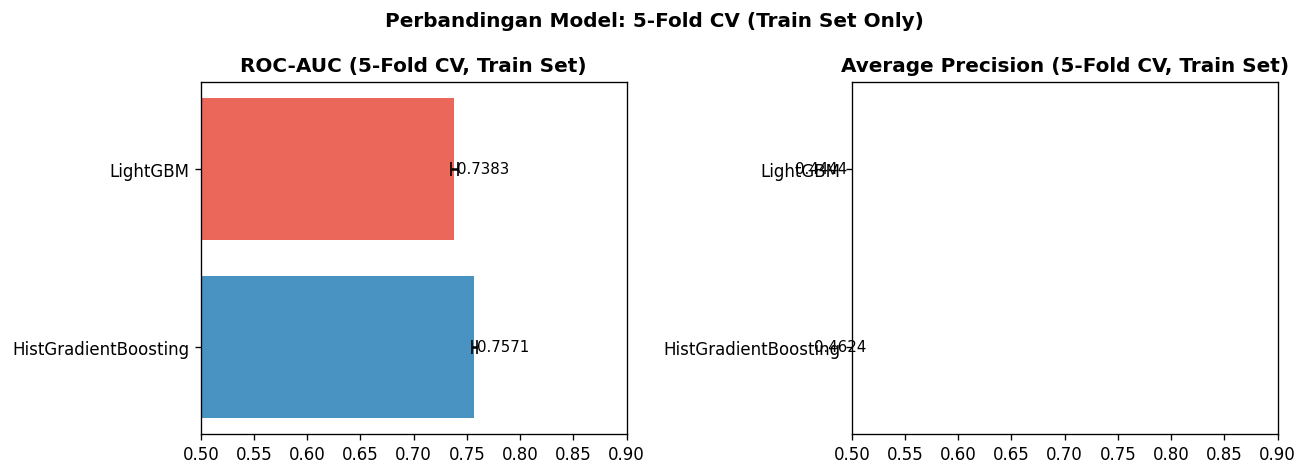

Selisih ROC-AUC (LightGBM - HistGB): -0.0188


In [23]:
cv_df = pd.DataFrame(cv_results).T

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
model_colors = ['#2980b9', '#e74c3c']

for ax, metric, err, title in [
    (axes[0], 'roc_auc_mean', 'roc_auc_std', 'ROC-AUC (5-Fold CV, Train Set)'),
    (axes[1], 'ap_mean',      'ap_std',       'Average Precision (5-Fold CV, Train Set)'),
]:
    bars = ax.barh(cv_df.index, cv_df[metric], xerr=cv_df[err],
                   capsize=4, color=model_colors, alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0.5, 0.9)
    for bar, val in zip(bars, cv_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Perbandingan Model: 5-Fold CV (Train Set Only)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '05_cv_comparison.png'), bbox_inches='tight')
plt.show()

diff = cv_results['LightGBM']['roc_auc_mean'] - cv_results['HistGradientBoosting']['roc_auc_mean']
print(f'Selisih ROC-AUC (LightGBM - HistGB): {diff:+.4f}')
if abs(diff) <= 0.01:
    print('Selisih <= 0.01: kedua model praktis setara dalam performa CV.')
    print('LightGBM dipilih berdasarkan alasan packaging & simulator readiness (lihat narasi di atas).')

## 8. Training Model Final (LightGBM)

### 8.1 Training LightGBM dengan Early Stopping pada Calibration-Val Set
Early stopping menggunakan `X_cal_df` / `y_cal` — **bukan** final test set.

In [24]:
lgbm_base = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=80,
    min_child_samples=30,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=spw,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_base.fit(
    X_train_df, y_train,
    eval_set=[(X_cal_df, y_cal)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=60, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

print(f'Best iteration (early stopping pada cal-val): {lgbm_base.best_iteration_}')

Best iteration (early stopping pada cal-val): 6


### 8.2 Kalibrasi Probabilitas dengan Isotonic Regression
Kalibrasi dilakukan menggunakan `X_cal_df` / `y_cal` — **bukan** final test set.
Tujuan: agar probabilitas yang dihasilkan merepresentasikan frekuensi aktual low rating (penting untuk risk simulator).

In [25]:
calibrated_lgbm = CalibratedClassifierCV(
    estimator=lgbm_base,
    method='isotonic',
    cv='prefit'
)
calibrated_lgbm.fit(X_cal_df, y_cal)
print('Model berhasil dikalibrasi menggunakan calibration-val set.')

Model berhasil dikalibrasi menggunakan calibration-val set.


### 8.3 Validasi Kalibrasi: Calibration Curve
Membandingkan probabilitas prediksi vs frekuensi aktual sebelum dan sesudah kalibrasi pada cal-val set.

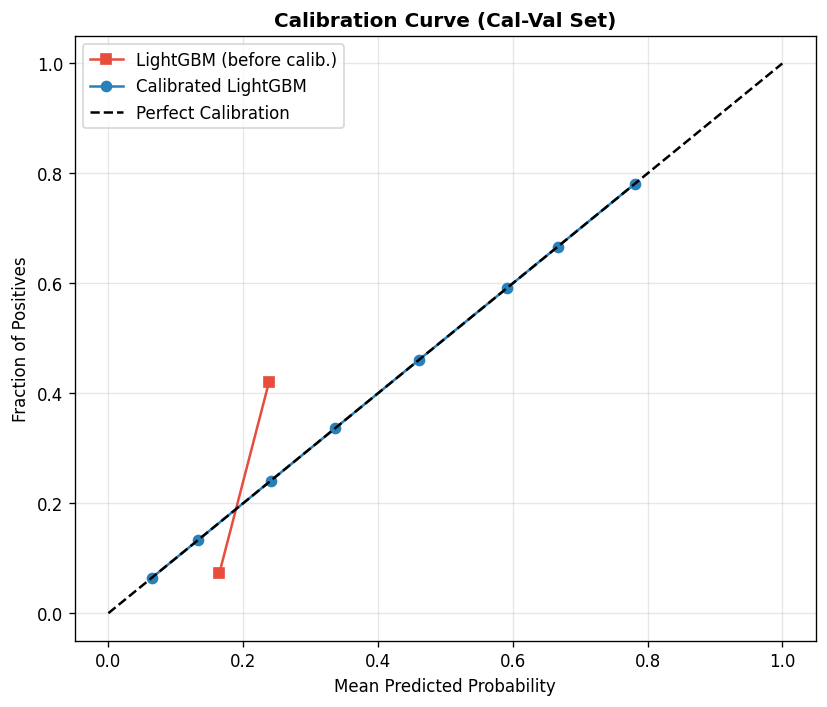

In [26]:
prob_before = lgbm_base.predict_proba(X_cal_df)[:, 1]
prob_after  = calibrated_lgbm.predict_proba(X_cal_df)[:, 1]

frac_b, mean_b = calibration_curve(y_cal, prob_before, n_bins=10)
frac_a, mean_a = calibration_curve(y_cal, prob_after,  n_bins=10)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_b, frac_b, 's-', color='#e74c3c', label='LightGBM (before calib.)')
ax.plot(mean_a, frac_a, 'o-', color='#2980b9', label='Calibrated LightGBM')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve (Cal-Val Set)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '06_calibration_curve.png'), bbox_inches='tight')
plt.show()

## 9. Evaluasi Final pada Test Set

> Final test set hanya digunakan **sekali di sini**. Tidak ada keputusan model yang dibuat berdasarkan data ini sebelumnya.

> **Catatan performa:** Model ini memiliki performa moderat, yang wajar untuk data e-commerce perilaku pelanggan.
> ROC-AUC di kisaran 0.70–0.77 sudah cukup untuk digunakan sebagai **risk scoring tool / simulator**,
> bukan sebagai sistem prediksi kausal atau operasional yang sangat akurat.

### 9.1 Prediksi Probabilitas pada Final Test Set

In [27]:
y_prob_test = calibrated_lgbm.predict_proba(X_test_df)[:, 1]

roc_auc_final = roc_auc_score(y_test, y_prob_test)
avg_prec_final = average_precision_score(y_test, y_prob_test)

print(f'ROC-AUC (Final Test)          : {roc_auc_final:.4f}')
print(f'Average Precision (Final Test): {avg_prec_final:.4f}')
print()
print('Interpretasi: ROC-AUC di rentang 0.70-0.77 adalah performa moderat yang ')
print('cukup untuk risk scoring simulator. Model tidak diklaim sebagai sistem prediksi kuat.')

ROC-AUC (Final Test)          : 0.7595
Average Precision (Final Test): 0.4623

Interpretasi: ROC-AUC di rentang 0.70-0.77 adalah performa moderat yang 
cukup untuk risk scoring simulator. Model tidak diklaim sebagai sistem prediksi kuat.


### 9.2 ROC Curve & Precision-Recall Curve

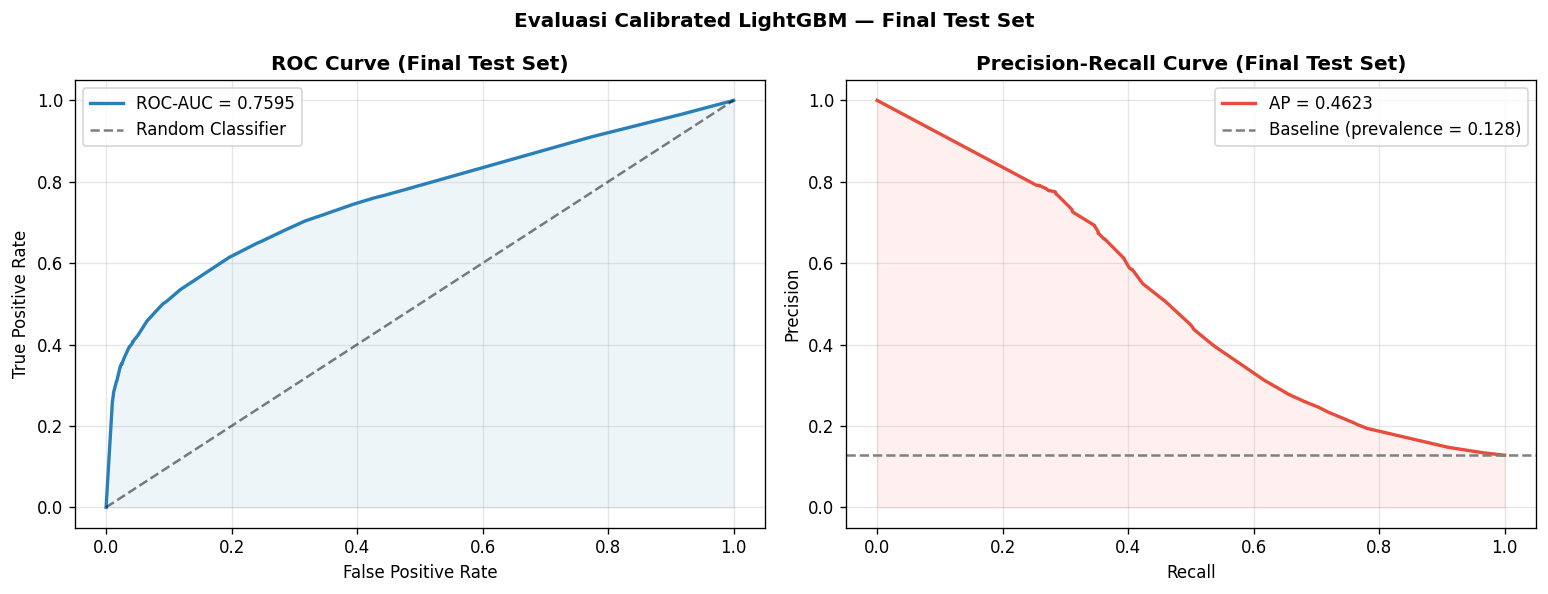

In [28]:
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
prec_pr, rec_pr, thr_pr = precision_recall_curve(y_test, y_prob_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#2980b9', linewidth=2, label=f'ROC-AUC = {roc_auc_final:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#2980b9')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Final Test Set)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PR Curve
axes[1].plot(rec_pr, prec_pr, color='#e74c3c', linewidth=2, label=f'AP = {avg_prec_final:.4f}')
baseline_pr = y_test.mean()
axes[1].axhline(y=baseline_pr, color='gray', linestyle='--',
                label=f'Baseline (prevalence = {baseline_pr:.3f})')
axes[1].fill_between(rec_pr, prec_pr, alpha=0.08, color='#e74c3c')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Final Test Set)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evaluasi Calibrated LightGBM — Final Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '07_roc_pr_curve.png'), bbox_inches='tight')
plt.show()

### 9.3 Threshold Analysis
Threshold 0.30 dipilih untuk memaksimalkan recall (sensitivity) — cocok untuk risk monitoring di mana
**missed low rating (false negative) lebih merugikan** daripada false alarm.

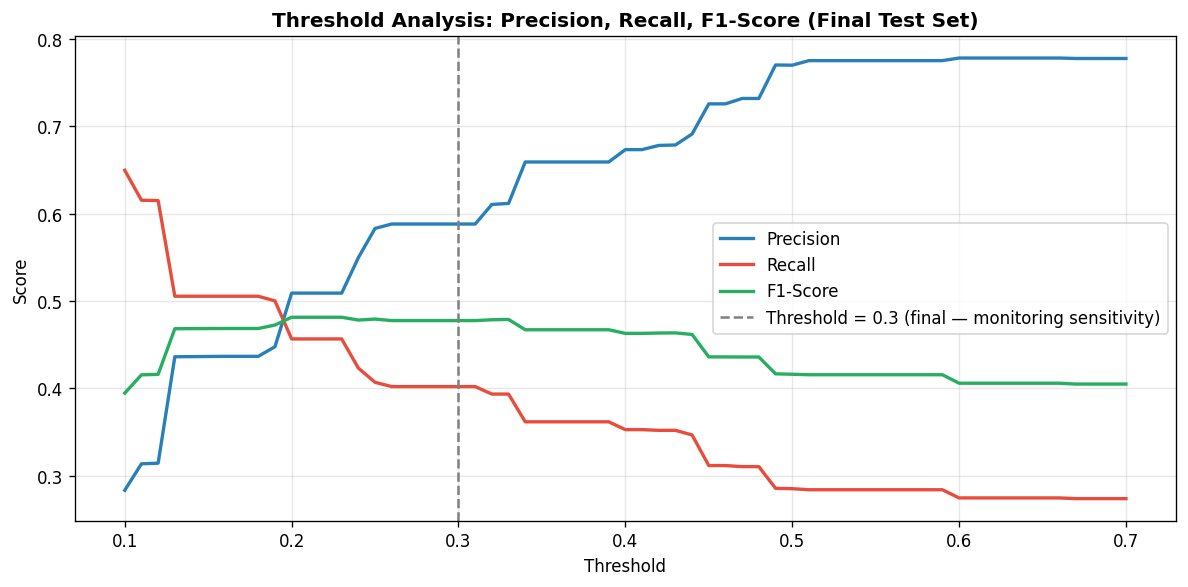

Metrik pada threshold 0.3:
  Precision : 0.5882
  Recall    : 0.4020
  F1-Score  : 0.4776


In [29]:
thresholds_eval = np.arange(0.10, 0.71, 0.01)
prec_list, rec_list, f1_list = [], [], []

for t in thresholds_eval:
    y_pred_t = (y_prob_test >= t).astype(int)
    prec_list.append(precision_score(y_test, y_pred_t, zero_division=0))
    rec_list.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1_list.append(f1_score(y_test, y_pred_t, zero_division=0))

FINAL_THRESHOLD = 0.30
idx_thr = np.argmin(np.abs(thresholds_eval - FINAL_THRESHOLD))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_eval, prec_list, label='Precision', color='#2980b9', linewidth=2)
ax.plot(thresholds_eval, rec_list,  label='Recall',    color='#e74c3c', linewidth=2)
ax.plot(thresholds_eval, f1_list,   label='F1-Score',  color='#27ae60', linewidth=2)
ax.axvline(x=FINAL_THRESHOLD, color='gray', linestyle='--', linewidth=1.5,
           label=f'Threshold = {FINAL_THRESHOLD} (final — monitoring sensitivity)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Analysis: Precision, Recall, F1-Score (Final Test Set)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '08_threshold_analysis.png'), bbox_inches='tight')
plt.show()

print(f'Metrik pada threshold {FINAL_THRESHOLD}:')
print(f'  Precision : {prec_list[idx_thr]:.4f}')
print(f'  Recall    : {rec_list[idx_thr]:.4f}')
print(f'  F1-Score  : {f1_list[idx_thr]:.4f}')

### 9.4 Confusion Matrix pada Threshold 0.30

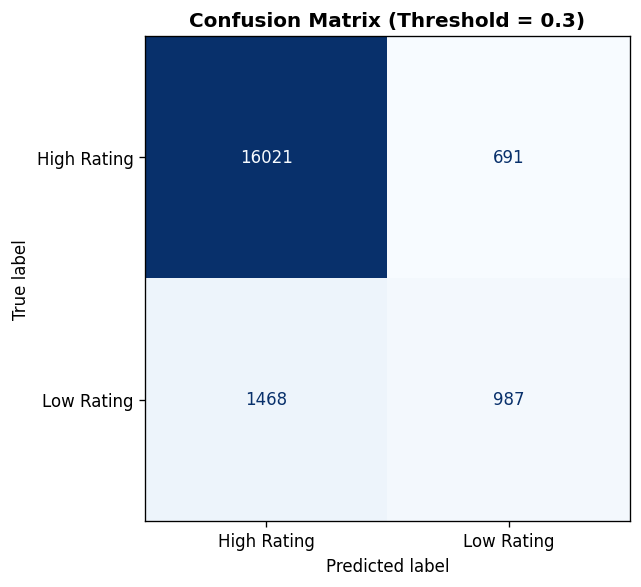

              precision    recall  f1-score   support

 High Rating       0.92      0.96      0.94     16712
  Low Rating       0.59      0.40      0.48      2455

    accuracy                           0.89     19167
   macro avg       0.75      0.68      0.71     19167
weighted avg       0.87      0.89      0.88     19167



In [30]:
y_pred_final = (y_prob_test >= FINAL_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['High Rating', 'Low Rating'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix (Threshold = {FINAL_THRESHOLD})', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '09_confusion_matrix.png'), bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_final,
                             target_names=['High Rating', 'Low Rating']))

### 9.5 Tabel Ringkasan Performa Final

In [31]:
# HistGradientBoosting pada final test untuk perbandingan
hgb_final = HistGradientBoostingClassifier(
    max_iter=500, learning_rate=0.05, max_depth=6,
    min_samples_leaf=30, random_state=RANDOM_STATE
)
hgb_final.fit(X_train_df, y_train)
hgb_calib = CalibratedClassifierCV(hgb_final, method='isotonic', cv='prefit')
hgb_calib.fit(X_cal_df, y_cal)
y_prob_hgb = hgb_calib.predict_proba(X_test_df)[:, 1]
y_pred_hgb = (y_prob_hgb >= FINAL_THRESHOLD).astype(int)

comparison = pd.DataFrame([
    {
        'Model': 'Calibrated HistGradientBoosting',
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob_hgb), 4),
        'Avg Prec':  round(average_precision_score(y_test, y_prob_hgb), 4),
        'Precision @0.30': round(precision_score(y_test, y_pred_hgb, zero_division=0), 4),
        'Recall @0.30':    round(recall_score(y_test, y_pred_hgb, zero_division=0), 4),
        'F1 @0.30':        round(f1_score(y_test, y_pred_hgb, zero_division=0), 4),
        'Selected': ''
    },
    {
        'Model': 'Calibrated LightGBM',
        'ROC-AUC':   round(roc_auc_final, 4),
        'Avg Prec':  round(avg_prec_final, 4),
        'Precision @0.30': round(prec_list[idx_thr], 4),
        'Recall @0.30':    round(rec_list[idx_thr], 4),
        'F1 @0.30':        round(f1_list[idx_thr], 4),
        'Selected': 'FINAL (packaging + simulator readiness)'
    },
])
comparison

,Model,ROC-AUC,Avg Prec,Precision @0.30,Recall @0.30,F1 @0.30,Selected
0,Calibrated HistGradientBoosting,0.7662,0.4693,0.5843,0.4106,0.4823,
1,Calibrated LightGBM,0.7595,0.4623,0.5882,0.4020,0.4776,FINAL (packaging + simulator readiness)


## 10. Feature Importance

### 10.1 LightGBM Feature Importance (Gain)
Gain importance mengukur seberapa banyak tiap fitur berkontribusi pada pengurangan loss saat splitting.

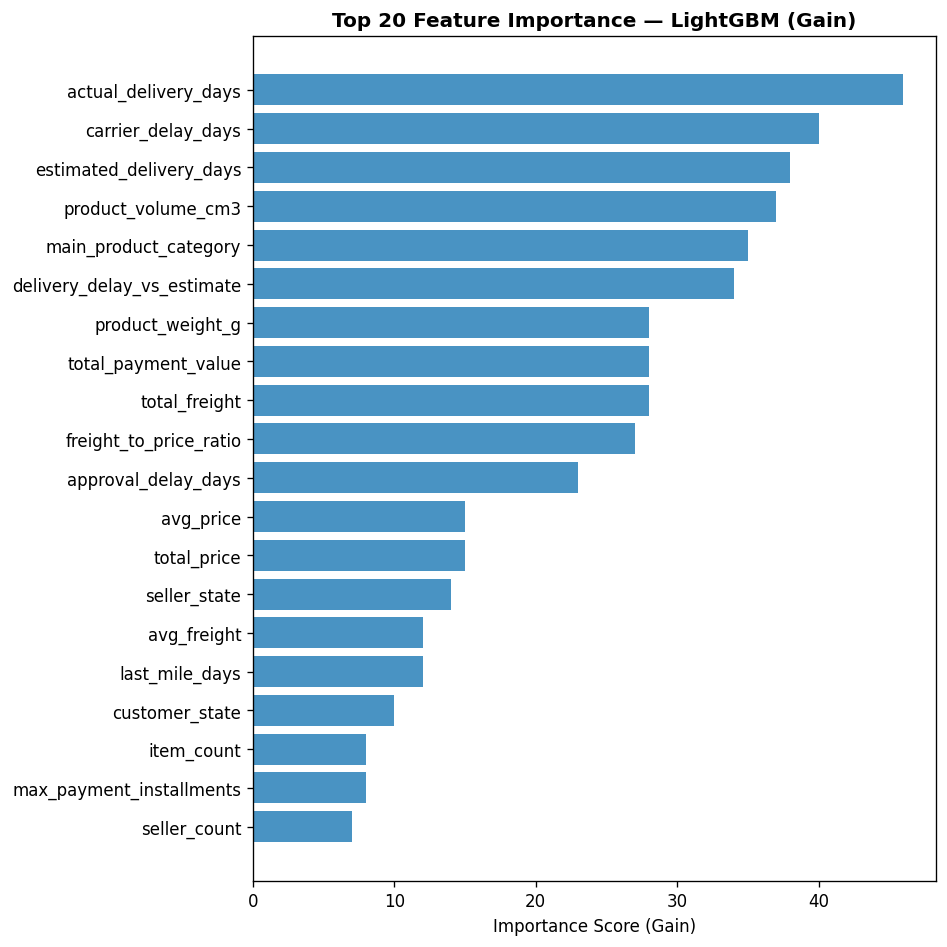

In [32]:
feat_imp_df = pd.DataFrame({
    'feature':    feature_names_out,
    'importance': lgbm_base.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(feat_imp_df['feature'], feat_imp_df['importance'], color='#2980b9', alpha=0.85)
ax.set_title('Top 20 Feature Importance — LightGBM (Gain)', fontweight='bold')
ax.set_xlabel('Importance Score (Gain)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '10_feature_importance_gain.png'), bbox_inches='tight')
plt.show()

### 10.2 Permutation Importance pada Cal-Val Set
Permutation importance mengukur penurunan ROC-AUC ketika nilai satu fitur diacak.
Diukur pada `X_cal_df` bukan final test set untuk menjaga final test tetap untouched.

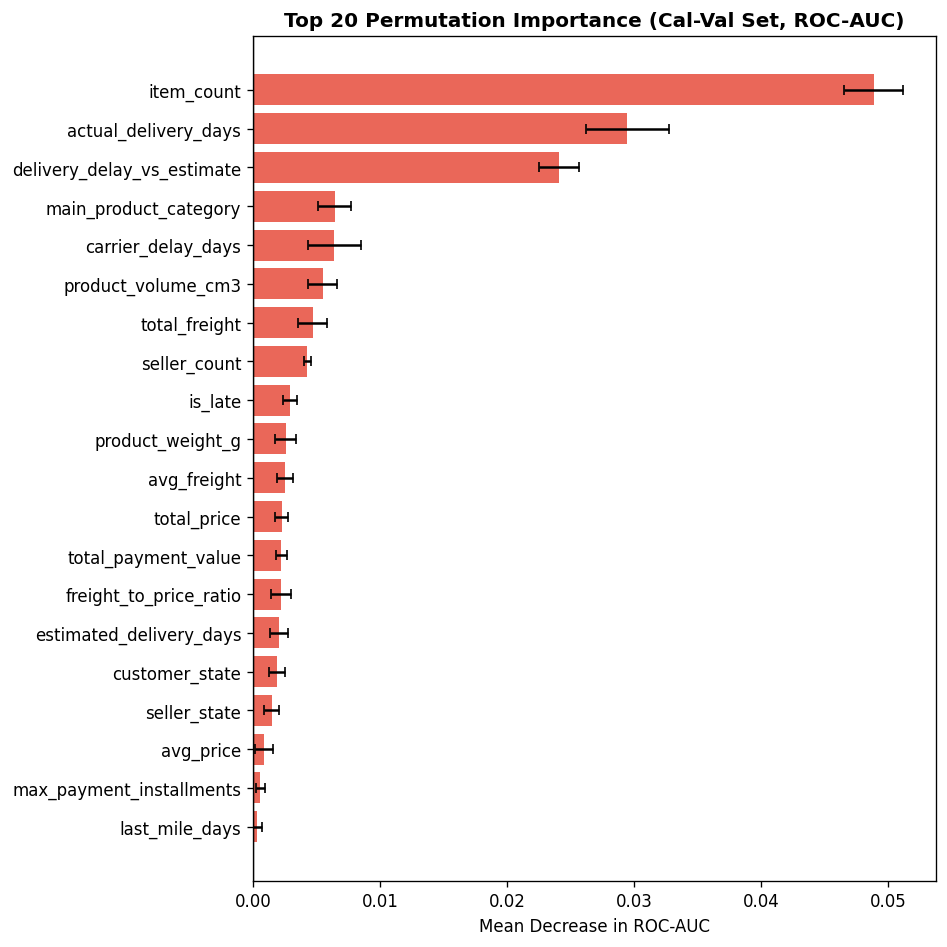

In [33]:
perm_result = permutation_importance(
    calibrated_lgbm, X_cal_df, y_cal,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':  feature_names_out,
    'mean_imp': perm_result.importances_mean,
    'std_imp':  perm_result.importances_std,
}).sort_values('mean_imp', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(perm_df['feature'], perm_df['mean_imp'],
        xerr=perm_df['std_imp'], color='#e74c3c', alpha=0.85, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Permutation Importance (Cal-Val Set, ROC-AUC)', fontweight='bold')
ax.set_xlabel('Mean Decrease in ROC-AUC')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '11_permutation_importance.png'), bbox_inches='tight')
plt.show()

## 11. Risk Score Distribution & Segmentasi Risk Level

### 11.1 Definisi Risk Level
| Risk Level | Probabilitas | Interpretasi |
|---|---|---|
| Low | < 0.30 | Risiko rendah, tidak perlu aksi khusus |
| Medium | 0.30 – 0.49 | Ada indikasi risiko, pertimbangkan follow-up |
| High | >= 0.50 | Risiko tinggi, prioritaskan proactive outreach |

In [34]:
def assign_risk_level(prob):
    if prob >= 0.50:
        return 'High'
    elif prob >= 0.30:
        return 'Medium'
    else:
        return 'Low'

def build_business_interpretation(risk_level, prob):
    pct = f'{prob*100:.1f}%'
    if risk_level == 'High':
        return (f'Estimasi risiko tinggi ({pct}). Berdasarkan pola delivery dan transaksi, '
                f'order ini memiliki indikasi risiko low rating yang lebih tinggi dari rata-rata. '
                f'Pertimbangkan proactive outreach setelah pengiriman.')
    elif risk_level == 'Medium':
        return (f'Estimasi risiko sedang ({pct}). Ada beberapa indikator yang perlu diperhatikan. '
                f'Follow-up post-delivery dapat membantu menjaga kepuasan customer.')
    else:
        return (f'Estimasi risiko rendah ({pct}). Pola order ini tidak menunjukkan indikator '
                f'risiko yang signifikan. Tetap pantau SLA pengiriman.')

print('Risk level functions defined.')

Risk level functions defined.


### 11.2 Distribusi Risk Score pada Final Test Set

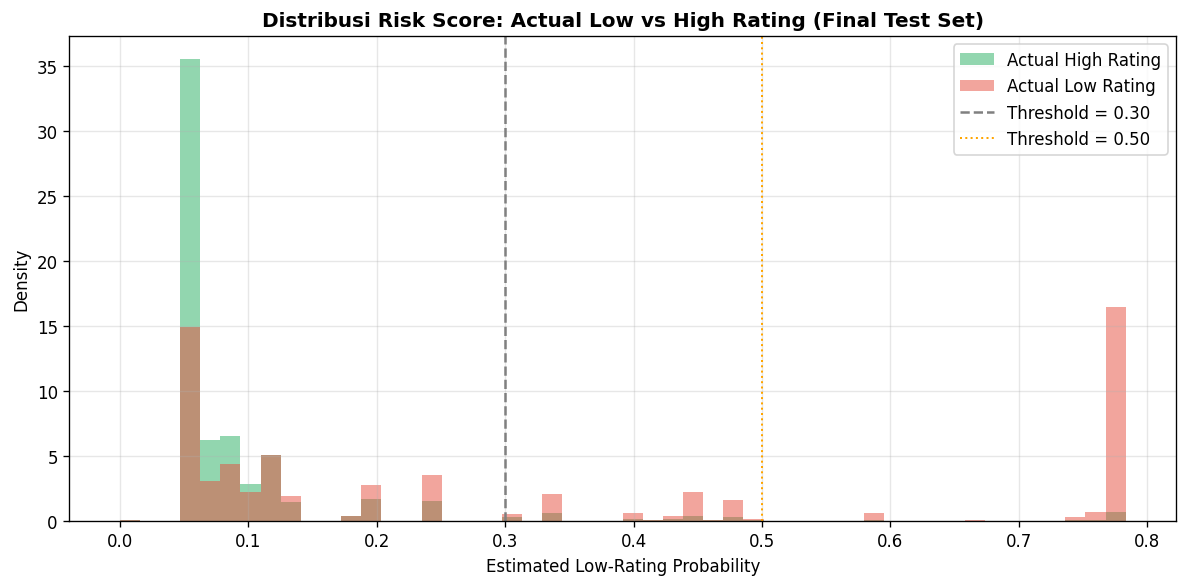

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
for lv, color, name in [(0, '#27ae60', 'Actual High Rating'), (1, '#e74c3c', 'Actual Low Rating')]:
    mask = (y_test.values == lv)
    ax.hist(y_prob_test[mask], bins=50, alpha=0.5, color=color, label=name, density=True)
ax.axvline(x=0.30, color='gray',   linestyle='--', linewidth=1.5, label='Threshold = 0.30')
ax.axvline(x=0.50, color='orange', linestyle=':',  linewidth=1.2, label='Threshold = 0.50')
ax.set_xlabel('Estimated Low-Rating Probability')
ax.set_ylabel('Density')
ax.set_title('Distribusi Risk Score: Actual Low vs High Rating (Final Test Set)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '12_risk_score_distribution.png'), bbox_inches='tight')
plt.show()

### 11.3 Risk Level Distribution pada Final Test Set

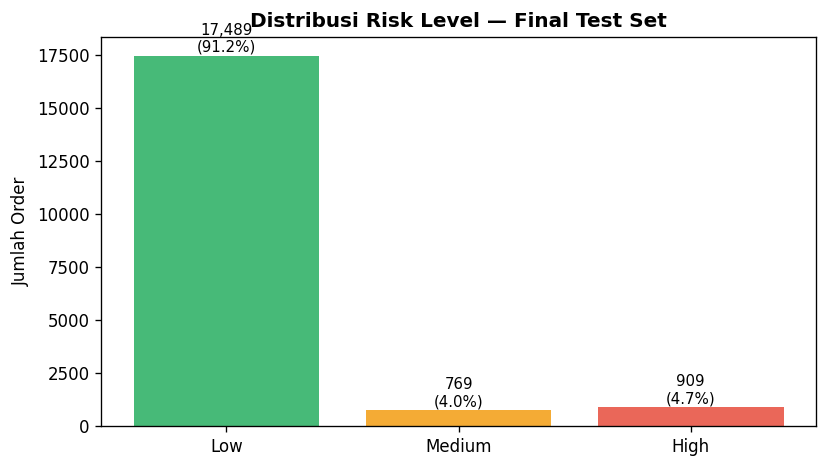

In [36]:
risk_levels_test = pd.Series(y_prob_test).apply(assign_risk_level)
risk_dist = risk_levels_test.value_counts().reindex(['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(7, 4))
rl_colors = ['#27ae60', '#f39c12', '#e74c3c']
bars = ax.bar(risk_dist.index, risk_dist.values, color=rl_colors, alpha=0.85)
ax.set_title('Distribusi Risk Level — Final Test Set', fontweight='bold')
ax.set_ylabel('Jumlah Order')
for bar, val in zip(bars, risk_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(y_prob_test)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '13_risk_level_distribution.png'), bbox_inches='tight')
plt.show()

### 11.4 Validasi Bisnis: Actual Low Rating Rate per Risk Level
Validasi bahwa risk level yang lebih tinggi memang berkorelasi dengan actual low rating yang lebih tinggi.

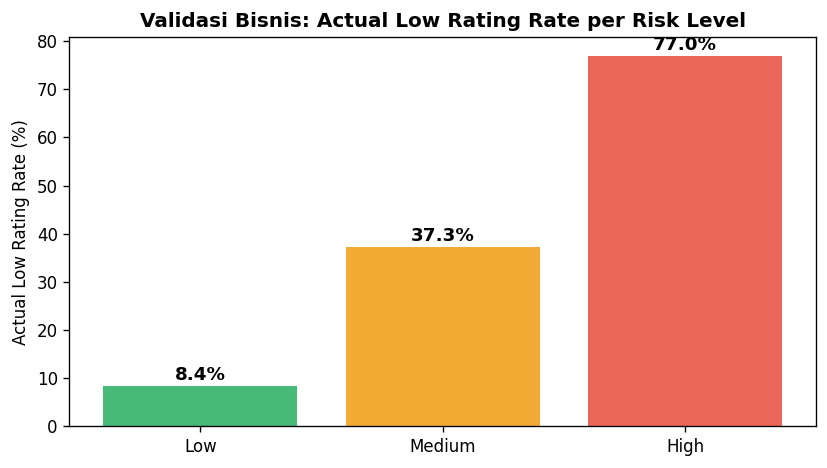

            n_orders  n_low_rating  actual_low_rate_pct
risk_level                                             
Low            17489          1468             8.393848
Medium           769           287            37.321196
High             909           700            77.007701


In [37]:
risk_val = pd.DataFrame({
    'risk_level':        risk_levels_test.values,
    'actual_low_rating': y_test.values
})
risk_summary = (
    risk_val.groupby('risk_level')
    .agg(n_orders=('actual_low_rating','count'),
         n_low_rating=('actual_low_rating','sum'),
         actual_low_rate=('actual_low_rating','mean'))
    .reindex(['Low','Medium','High'])
)
risk_summary['actual_low_rate_pct'] = risk_summary['actual_low_rate'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(risk_summary.index, risk_summary['actual_low_rate_pct'],
              color=rl_colors, alpha=0.85)
ax.set_ylabel('Actual Low Rating Rate (%)')
ax.set_title('Validasi Bisnis: Actual Low Rating Rate per Risk Level', fontweight='bold')
for bar, val in zip(bars, risk_summary['actual_low_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, '14_risk_level_validation.png'), bbox_inches='tight')
plt.show()

print(risk_summary[['n_orders', 'n_low_rating', 'actual_low_rate_pct']])

## 12. Generate Output Prediksi untuk Simulator

### 12.1 Prediksi pada Seluruh Dataset
Prediksi dijalankan pada seluruh `df_ml` menggunakan preprocessor dan model yang sudah di-fit.
Ini adalah output akhir yang akan digunakan sebagai referensi risk score untuk simulator.

In [38]:
X_all_p = preprocessor.transform(X_all)
X_all_df = pd.DataFrame(X_all_p, columns=feature_names_out)

all_probs = calibrated_lgbm.predict_proba(X_all_df)[:, 1]

output_df = df_ml[['order_id']].copy().reset_index(drop=True)
output_df['low_rating_risk']            = np.round(all_probs, 4)
output_df['low_rating_risk_percentage'] = np.round(all_probs * 100, 2)
output_df['risk_level']                 = [assign_risk_level(p) for p in all_probs]
output_df['business_interpretation']    = [
    build_business_interpretation(rl, p)
    for rl, p in zip(output_df['risk_level'], all_probs)
]
output_df['actual_low_rating'] = df_ml[TARGET_COL].values
output_df['review_score']      = df_ml['review_score'].values

print(f'Output DataFrame: {output_df.shape}')
output_df.head(3)

Output DataFrame: (95832, 7)


,order_id,low_rating_risk,low_rating_risk_percentage,risk_level,business_interpretation,actual_low_rating,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,0.061,6.1,Low,Estimasi risiko rendah (6.1%). Pola order ini ...,0,4
1,53cdb2fc8bc7dce0b6741e2150273451,0.061,6.1,Low,Estimasi risiko rendah (6.1%). Pola order ini ...,0,4
2,47770eb9100c2d0c44946d9cf07ec65d,0.061,6.1,Low,Estimasi risiko rendah (6.1%). Pola order ini ...,0,5


### 12.2 Simpan Output Risk CSV ke Drive

In [39]:
output_csv_path = os.path.join(BASE_PATH, 'ml_low_rating_risk_output.csv')
output_df.to_csv(output_csv_path, index=False)
print(f'Risk output CSV disimpan: {output_csv_path}')
print(f'Shape: {output_df.shape}')

Risk output CSV disimpan: /content/drive/MyDrive/FP_MCI_Data/Dataset/ml_low_rating_risk_output.csv
Shape: (95832, 7)


## 13. Simpan Artifact Lengkap ke Drive

### 13.1 Model PKL: Calibrated LightGBM & Preprocessor

In [40]:
# Model final: Calibrated LightGBM
model_path = os.path.join(MODEL_PATH, 'calibrated_lgbm_low_rating.pkl')
joblib.dump(calibrated_lgbm, model_path)
print(f'Model disimpan: {model_path}')

# Model raw LightGBM (untuk SHAP / analisis lanjutan)
lgbm_raw_path = os.path.join(MODEL_PATH, 'lgbm_raw_low_rating.pkl')
joblib.dump(lgbm_base, lgbm_raw_path)
print(f'LightGBM raw disimpan: {lgbm_raw_path}')

# Preprocessor pipeline (imputer + encoder)
preproc_path = os.path.join(MODEL_PATH, 'preprocessor.pkl')
joblib.dump(preprocessor, preproc_path)
print(f'Preprocessor disimpan: {preproc_path}')

Model disimpan: /content/drive/MyDrive/FP_MCI_Data/Dataset/models/calibrated_lgbm_low_rating.pkl
LightGBM raw disimpan: /content/drive/MyDrive/FP_MCI_Data/Dataset/models/lgbm_raw_low_rating.pkl
Preprocessor disimpan: /content/drive/MyDrive/FP_MCI_Data/Dataset/models/preprocessor.pkl


### 13.2 Feature Schema & Metadata JSON

In [41]:
feature_schema = {
    'model_name':    'Calibrated LightGBM (isotonic)',
    'framing':       'Post-delivery low-rating risk estimator',
    'version':       '2.0',
    'target_column': TARGET_COL,
    'label_definition': {'low_rating_1': 'review_score <= 2', 'low_rating_0': 'review_score > 2'},
    'feature_columns':  FEATURE_COLS,
    'numeric_features': NUM_COLS,
    'categorical_features': CAT_COLS,
    'feature_names_after_transform': feature_names_out,
    'split_strategy': {
        'train':        '60% (fit model & preprocessor)',
        'cal_val':      '20% (early stopping & calibration)',
        'final_test':   '20% (evaluation only, untouched)'
    },
    'final_threshold': FINAL_THRESHOLD,
    'risk_level_thresholds': {
        'Low':    'prob < 0.30',
        'Medium': '0.30 <= prob < 0.50',
        'High':   'prob >= 0.50'
    },
    'performance_final_test': {
        'roc_auc':         round(roc_auc_final, 4),
        'avg_precision':   round(avg_prec_final, 4),
        'precision_at_thr': round(prec_list[idx_thr], 4),
        'recall_at_thr':    round(rec_list[idx_thr], 4),
        'f1_at_thr':        round(f1_list[idx_thr], 4),
    },
    'performance_note': (
        'Performa moderat (ROC-AUC ~0.70-0.77), cukup untuk risk simulator. '
        'Tidak diklaim sebagai model prediksi kausal atau operasional yang sangat kuat.'
    ),
    'data_leakage_guards': [
        'review_comment_title dan review_comment_message tidak digunakan',
        'Fitur historis berbasis review score tidak digunakan',
        'Preprocessor di-fit hanya pada X_train',
        'Final test set tidak disentuh hingga evaluasi akhir',
        'Early stopping menggunakan cal_val set, bukan final test'
    ],
    'n_train':    int(X_train.shape[0]),
    'n_cal_val':  int(X_cal.shape[0]),
    'n_test':     int(X_test.shape[0]),
    'n_features': len(FEATURE_COLS),
    'lgbm_best_iteration': int(lgbm_base.best_iteration_),
}

schema_path = os.path.join(MODEL_PATH, 'feature_schema.json')
with open(schema_path, 'w') as f:
    json.dump(feature_schema, f, indent=2)
print(f'Feature schema disimpan: {schema_path}')

Feature schema disimpan: /content/drive/MyDrive/FP_MCI_Data/Dataset/models/feature_schema.json


### 13.3 Sample Input JSON untuk App/Simulator

In [42]:
# Ambil 3 contoh dari dataset: 1 Low risk, 1 Medium risk, 1 High risk
sample_records = []
for target_rl in ['Low', 'Medium', 'High']:
    mask = output_df['risk_level'] == target_rl
    if mask.sum() > 0:
        sample_idx = output_df[mask].index[0]
        row = df_ml.iloc[sample_idx]
        record = {
            '_example_risk_level': target_rl,
            '_example_low_rating_risk': float(output_df.loc[sample_idx, 'low_rating_risk']),
        }
        for col in FEATURE_COLS:
            val = row[col]
            record[col] = None if pd.isna(val) else (int(val) if isinstance(val, (np.integer,)) else
                                                     float(val) if isinstance(val, (float, np.floating)) else str(val))
        sample_records.append(record)

sample_json_path = os.path.join(MODEL_PATH, 'sample_inputs.json')
with open(sample_json_path, 'w') as f:
    json.dump(sample_records, f, indent=2, default=str)
print(f'Sample inputs JSON disimpan: {sample_json_path}')
print(f'Jumlah contoh: {len(sample_records)}')

Sample inputs JSON disimpan: /content/drive/MyDrive/FP_MCI_Data/Dataset/models/sample_inputs.json
Jumlah contoh: 3


### 13.4 Prediction Helper Script
Script Python siap pakai untuk melakukan prediksi dari input baru menggunakan model yang sudah disimpan.

In [43]:
helper_script = '''
"""
predict_risk.py
Helper script untuk prediksi low-rating risk menggunakan model yang sudah di-train.
Model: Post-Delivery Low-Rating Risk Estimator (Calibrated LightGBM)
Framing: Risk scoring tool — bukan sistem prediksi operasional.
"""
import joblib
import json
import numpy as np
import pandas as pd
import os

MODEL_DIR = '/content/drive/MyDrive/FP_MCI_Data/Dataset/models'


def load_artifacts():
    """Load model, preprocessor, dan schema dari Drive."""
    model       = joblib.load(os.path.join(MODEL_DIR, 'calibrated_lgbm_low_rating.pkl'))
    preprocessor = joblib.load(os.path.join(MODEL_DIR, 'preprocessor.pkl'))
    with open(os.path.join(MODEL_DIR, 'feature_schema.json')) as f:
        schema = json.load(f)
    return model, preprocessor, schema


def assign_risk_level(prob):
    if prob >= 0.50:
        return 'High'
    elif prob >= 0.30:
        return 'Medium'
    return 'Low'


def predict_risk(input_dict, model, preprocessor, schema):
    """
    Melakukan prediksi untuk satu order.

    Parameters
    ----------
    input_dict : dict
        Dictionary dengan key = nama fitur (sesuai schema['feature_columns']).
    model : sklearn estimator
        Model calibrated yang sudah di-load.
    preprocessor : ColumnTransformer
        Preprocessor yang sudah di-fit pada training data.
    schema : dict
        Feature schema dari feature_schema.json.

    Returns
    -------
    dict : low_rating_risk, low_rating_risk_percentage, risk_level
    """
    feature_cols = schema['feature_columns']
    input_df = pd.DataFrame([input_dict])[feature_cols]
    X_transformed = preprocessor.transform(input_df)
    feature_names = schema['feature_names_after_transform']
    X_df = pd.DataFrame(X_transformed, columns=feature_names)
    prob = model.predict_proba(X_df)[0, 1]
    risk_level = assign_risk_level(prob)
    return {
        'low_rating_risk':            round(float(prob), 4),
        'low_rating_risk_percentage': round(float(prob) * 100, 2),
        'risk_level':                 risk_level,
    }


def predict_batch(df_input, model, preprocessor, schema):
    """
    Melakukan prediksi batch untuk DataFrame input.

    Parameters
    ----------
    df_input : pd.DataFrame
        DataFrame dengan kolom sesuai schema['feature_columns'].

    Returns
    -------
    pd.DataFrame : DataFrame input + kolom prediksi
    """
    feature_cols = schema['feature_columns']
    X_transformed = preprocessor.transform(df_input[feature_cols])
    feature_names = schema['feature_names_after_transform']
    X_df = pd.DataFrame(X_transformed, columns=feature_names)
    probs = model.predict_proba(X_df)[:, 1]
    result = df_input.copy()
    result['low_rating_risk']            = np.round(probs, 4)
    result['low_rating_risk_percentage'] = np.round(probs * 100, 2)
    result['risk_level']                 = [assign_risk_level(p) for p in probs]
    return result


# Contoh penggunaan
if __name__ == "__main__":
    model, preprocessor, schema = load_artifacts()
    with open(os.path.join(MODEL_DIR, 'sample_inputs.json')) as f:
        samples = json.load(f)
    # Prediksi satu input
    sample = {k: v for k, v in samples[0].items() if not k.startswith('_')}
    result = predict_risk(sample, model, preprocessor, schema)
    print('Sample prediction:', result)
'''

helper_path = os.path.join(MODEL_PATH, 'predict_risk.py')
with open(helper_path, 'w') as f:
    f.write(helper_script.strip())
print(f'Helper script disimpan: {helper_path}')

Helper script disimpan: /content/drive/MyDrive/FP_MCI_Data/Dataset/models/predict_risk.py


## 14. Ringkasan Akhir & Daftar Artefak

### 14.1 Ringkasan Performa Model

In [44]:
print('ML Component: Post-Delivery Low-Rating Risk Estimator')
print(f'Model Final  : Calibrated LightGBM (isotonic)')
print(f'Dataset      : {len(df_ml):,} delivered orders dengan review')
print(f'Split        : Train {len(X_train):,} / Cal-Val {len(X_cal):,} / Test {len(X_test):,}')
print(f'Features     : {len(FEATURE_COLS)} fitur')
print(f'Low Rating   : {df_ml[TARGET_COL].mean()*100:.1f}% dari total orders')
print()
print('Performa Final Test Set (untouched):')
print(f'  ROC-AUC           : {roc_auc_final:.4f}')
print(f'  Average Precision : {avg_prec_final:.4f}')
print(f'  Precision @{FINAL_THRESHOLD}   : {prec_list[idx_thr]:.4f}')
print(f'  Recall    @{FINAL_THRESHOLD}   : {rec_list[idx_thr]:.4f}')
print(f'  F1-Score  @{FINAL_THRESHOLD}   : {f1_list[idx_thr]:.4f}')
print()
print('Catatan Performa:')
print('  Performa moderat — cukup untuk risk scoring simulator.')
print('  Tidak diklaim sebagai model prediksi kausal atau sistem operasional yang sangat akurat.')
print()
print('Artefak tersimpan di Drive:')
artifacts = [
    ('models/', 'calibrated_lgbm_low_rating.pkl', 'Model utama (final)'),
    ('models/', 'lgbm_raw_low_rating.pkl',         'LightGBM sebelum kalibrasi'),
    ('models/', 'preprocessor.pkl',               'Imputer + Encoder pipeline'),
    ('models/', 'feature_schema.json',             'Feature schema & metadata'),
    ('models/', 'sample_inputs.json',              'Sample input JSON untuk app'),
    ('models/', 'predict_risk.py',                 'Prediction helper script'),
    ('',        'ml_low_rating_risk_output.csv',   'Risk score seluruh dataset'),
    ('plots/',  '01 s/d 14 *.png',                 'Semua visualisasi evaluasi'),
]
for folder, fname, desc in artifacts:
    print(f'  {folder}{fname:<45s} — {desc}')

ML Component: Post-Delivery Low-Rating Risk Estimator
Model Final  : Calibrated LightGBM (isotonic)
Dataset      : 95,832 delivered orders dengan review
Split        : Train 57,498 / Cal-Val 19,167 / Test 19,167
Features     : 24 fitur
Low Rating   : 12.8% dari total orders

Performa Final Test Set (untouched):
  ROC-AUC           : 0.7595
  Average Precision : 0.4623
  Precision @0.3   : 0.5882
  Recall    @0.3   : 0.4020
  F1-Score  @0.3   : 0.4776

Catatan Performa:
  Performa moderat — cukup untuk risk scoring simulator.
  Tidak diklaim sebagai model prediksi kausal atau sistem operasional yang sangat akurat.

Artefak tersimpan di Drive:
  models/calibrated_lgbm_low_rating.pkl                — Model utama (final)
  models/lgbm_raw_low_rating.pkl                       — LightGBM sebelum kalibrasi
  models/preprocessor.pkl                              — Imputer + Encoder pipeline
  models/feature_schema.json                           — Feature schema & metadata
  models/sample_inputs